In [2]:
# Re-run the previous DEA code but instead of displaying interactive dataframes, we will print them out directly.

import numpy as np
import pandas as pd

# Data
inputs = np.array([[4, 20], [5, 30], [6, 25]])
outputs = np.array([[95, 98], [97, 99], [96, 97]])

countries = [f"Country {i}" for i in range(len(inputs))]
input_names = ["x1_spending", "x2_pupil_teacher"]
output_names = ["y1_completion", "y2_enrollment"]

raw_df = pd.DataFrame(
    np.hstack([inputs, outputs]),
    columns=input_names + output_names,
    index=countries
)

from scipy.optimize import linprog

def dea_opt_for_unit(i):
    n_units, m = inputs.shape
    _, s = outputs.shape
    c = np.zeros(s + m)
    c[:s] = -outputs[i]
    A_ub = np.zeros((n_units, s + m))
    b_ub = np.zeros(n_units)
    for k in range(n_units):
        A_ub[k, :s] = outputs[k]
        A_ub[k, s:] = -inputs[k]
    A_eq = np.zeros((1, s + m))
    A_eq[0, s:] = inputs[i]
    b_eq = np.array([1.0])
    bounds = [(0, None)] * (s + m)
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method="highs")
    if not res.success:
        return None
    z = res.x
    w_opt = z[:s]
    v_opt = z[s:]
    eff = outputs[i] @ w_opt
    return w_opt, v_opt, eff

results = []
for i in range(len(inputs)):
    out = dea_opt_for_unit(i)
    if out is None:
        results.append([countries[i], None, None, None, None, None])
    else:
        w_opt, v_opt, eff = out
        results.append([countries[i], w_opt[0], w_opt[1], v_opt[0], v_opt[1], eff])

res_df = pd.DataFrame(results, columns=["country","w_y1_completion","w_y2_enrollment",
                                        "v_x1_spending","v_x2_pupil_teacher","efficiency"])

print("=== DEA Input/Output Data ===")
print(raw_df)
print("\n=== DEA Optimal Weights and Efficiency by Country ===")
print(res_df.to_string(index=False))

=== DEA Input/Output Data ===
           x1_spending  x2_pupil_teacher  y1_completion  y2_enrollment
Country 0            4                20             95             98
Country 1            5                30             97             99
Country 2            6                25             96             97

=== DEA Optimal Weights and Efficiency by Country ===
  country  w_y1_completion  w_y2_enrollment  v_x1_spending  v_x2_pupil_teacher  efficiency
Country 0         0.010526              0.0            0.0                0.05    1.000000
Country 1         0.008421              0.0            0.2                0.00    0.816842
Country 2         0.008421              0.0            0.0                0.04    0.808421


In [6]:
# DEA for 100 countries — Input-oriented (CCR) model
# Prints (no GUI): data + optimal weights (w for outputs, v for inputs) + efficiency for all countries

import numpy as np
from scipy.optimize import linprog

# --------------------------
# 1) Generate synthetic data
# --------------------------
np.random.seed(42)  # reproducible

n = 100
countries = [f"Country {i+1}" for i in range(n)]

# Inputs
# x1: government spending on education (% of GDP): ~[2, 8]
# x2: pupil–teacher ratio: integer ~[10, 40]
x1_spending = np.random.uniform(2, 8, n).round(2)
x2_ptratio  = np.random.randint(10, 41, n).astype(float)

# Outputs
# y1: completion rate (%): ~[70, 100]
# y2: enrollment rate (%): ~[75, 100]
y1_completion = np.random.uniform(70, 100, n).round(1)
y2_enrollment = np.random.uniform(75, 100, n).round(1)

inputs  = np.column_stack([x1_spending, x2_ptratio])   # shape (n, m=2)
outputs = np.column_stack([y1_completion, y2_enrollment])  # shape (n, s=2)

# --------------------------
# 2) DEA solver (input-oriented)
#    Max sum_o w_o * y_{oi}
#    s.t. sum_j v_j * x_{ji} = 1                   (normalization)
#         sum_o w_o*y_{ok} - sum_j v_j*x_{jk} <= 0  for all k (fairness)
#         w_o >= 0, v_j >= 0
# --------------------------
def dea_opt_for_unit(i, inputs, outputs):
    n_units, m = inputs.shape
    _, s = outputs.shape

    # Decision vector z = [w_0..w_{s-1}, v_0..v_{m-1}]
    # linprog minimizes, so set c to negative of desired objective for unit i
    c = np.zeros(s + m)
    c[:s] = -outputs[i]  # maximize w·y_i  <=> minimize -(w·y_i)

    # A_ub z <= b_ub  (efficiency constraints for all k)
    A_ub = np.zeros((n_units, s + m))
    b_ub = np.zeros(n_units)
    for k in range(n_units):
        A_ub[k, :s] = outputs[k]
        A_ub[k, s:] = -inputs[k]

    # A_eq z = b_eq   (normalization for evaluated unit i)
    A_eq = np.zeros((1, s + m))
    A_eq[0, s:] = inputs[i]
    b_eq = np.array([1.0])

    # bounds for w and v: non-negativity
    bounds = [(0, None)] * (s + m)

    res = linprog(c, A_ub=A_ub, b_ub=b_ub,
                  A_eq=A_eq, b_eq=b_eq,
                  bounds=bounds, method="highs")

    if not res.success:
        return None, None, None, False

    z = res.x
    w_opt = z[:s]
    v_opt = z[s:]
    eff   = float(outputs[i] @ w_opt)  # denominator normalized to 1

    return w_opt, v_opt, eff, True

# --------------------------
# 3) Print data + weights
# --------------------------

# Print header
print("=== DEA Input/Output Data for 100 Countries ===")
print("Country\tx1_spending(%GDP)\tx2_pupil_teacher\ty1_completion(%)\ty2_enrollment(%)")
for i in range(n):
    print(f"{countries[i]}\t{x1_spending[i]:.2f}\t{x2_ptratio[i]:.0f}\t{y1_completion[i]:.1f}\t{y2_enrollment[i]:.1f}")

print("\n=== DEA Optimal Weights (w for outputs, v for inputs) and Efficiency (Input-oriented) ===")
print("Country\tw_y1_completion\tw_y2_enrollment\tv_x1_spending\tv_x2_pupil_teacher\tefficiency")

for i in range(n):
    w, v, eff, ok = dea_opt_for_unit(i, inputs, outputs)
    if not ok:
        print(f"{countries[i]}\tSOLVE_FAILED\t-\t-\t-\t-")
    else:
        print(f"{countries[i]}\t{w[0]:.6f}\t{w[1]:.6f}\t{v[0]:.6f}\t{v[1]:.6f}\t{eff:.6f}")

# --------------------------
# Notes:
# - This is the basic CCR (Charnes, Cooper, Rhodes) input-oriented model.
# - Corner solutions are common (e.g., w_y2 = 0). If you need weight restrictions,
#   add bounds or Assurance Region (AR) constraints to keep weights within ranges.
# --------------------------


=== DEA Input/Output Data for 100 Countries ===
Country	x1_spending(%GDP)	x2_pupil_teacher	y1_completion(%)	y2_enrollment(%)
Country 1	4.25	40	83.4	87.1
Country 2	7.70	16	86.6	84.3
Country 3	6.39	26	87.8	84.9
Country 4	5.59	29	72.4	96.1
Country 5	2.94	38	81.1	98.3
Country 6	2.94	13	77.3	76.8
Country 7	2.35	39	94.1	80.2
Country 8	7.20	14	84.1	91.8
Country 9	5.61	32	99.5	84.0
Country 10	6.25	16	82.0	81.4
Country 11	2.12	22	94.5	82.4
Country 12	7.82	24	94.0	83.1
Country 13	6.99	20	74.5	96.2
Country 14	3.27	38	85.2	78.4
Country 15	3.09	13	90.9	92.7
Country 16	3.10	22	95.8	88.8
Country 17	3.83	16	79.8	82.4
Country 18	5.15	36	76.6	85.5
Country 19	4.59	28	91.3	81.4
Country 20	3.75	31	94.3	90.3
Country 21	5.67	37	80.5	77.0
Country 22	2.84	11	72.9	75.1
Country 23	3.75	19	98.2	90.7
Country 24	4.20	22	81.9	79.9
Country 25	4.74	39	85.5	76.8
Country 26	6.71	34	95.1	84.9
Country 27	3.20	30	90.3	76.3
Country 28	5.09	15	92.1	97.2
Country 29	5.55	37	76.3	75.7
Country 30	2.28	37	86.2	89.5
Country 31	5.6

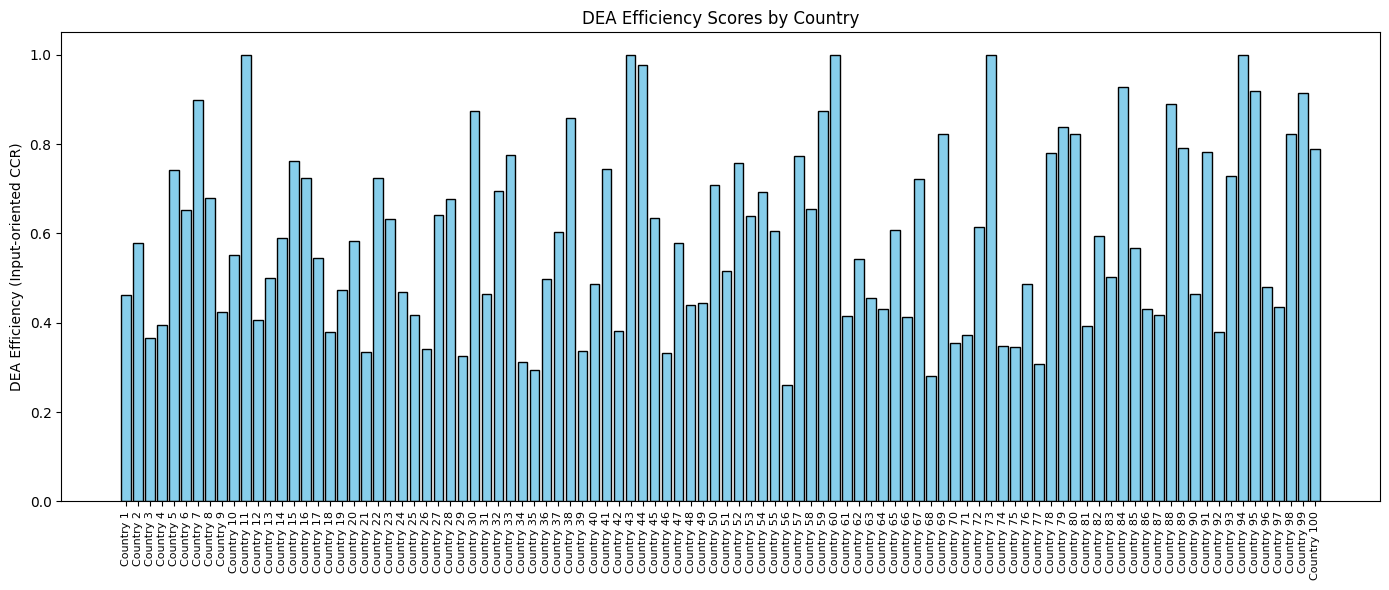

In [7]:
# --------------------------
# 4) Plot efficiency results
# --------------------------
import matplotlib.pyplot as plt

def plot_efficiencies(countries, inputs, outputs):
    efficiencies = []
    for i in range(len(countries)):
        w, v, eff, ok = dea_opt_for_unit(i, inputs, outputs)
        efficiencies.append(eff if ok else np.nan)

    plt.figure(figsize=(14, 6))
    plt.bar(countries, efficiencies, color="skyblue", edgecolor="black")
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("DEA Efficiency (Input-oriented CCR)")
    plt.title("DEA Efficiency Scores by Country")
    plt.tight_layout()
    plt.show()

# Call the plot function
plot_efficiencies(countries, inputs, outputs)


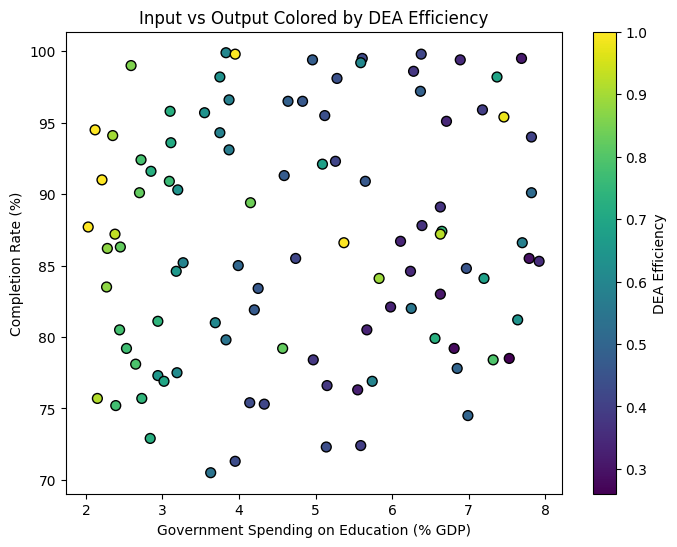

In [9]:
def plot_input_output_scatter(inputs, outputs, countries):
    efficiencies = []
    for i in range(len(countries)):
        w, v, eff, ok = dea_opt_for_unit(i, inputs, outputs)
        efficiencies.append(eff if ok else np.nan)

    efficiencies = np.array(efficiencies)

    plt.figure(figsize=(8,6))
    sc = plt.scatter(inputs[:,0], outputs[:,0], 
                     c=efficiencies, cmap="viridis", s=50, edgecolor="k")
    plt.colorbar(sc, label="DEA Efficiency")
    plt.xlabel("Government Spending on Education (% GDP)")
    plt.ylabel("Completion Rate (%)")
    plt.title("Input vs Output Colored by DEA Efficiency")
    plt.show()
# Call the plot function
plot_input_output_scatter(inputs, outputs, countries)


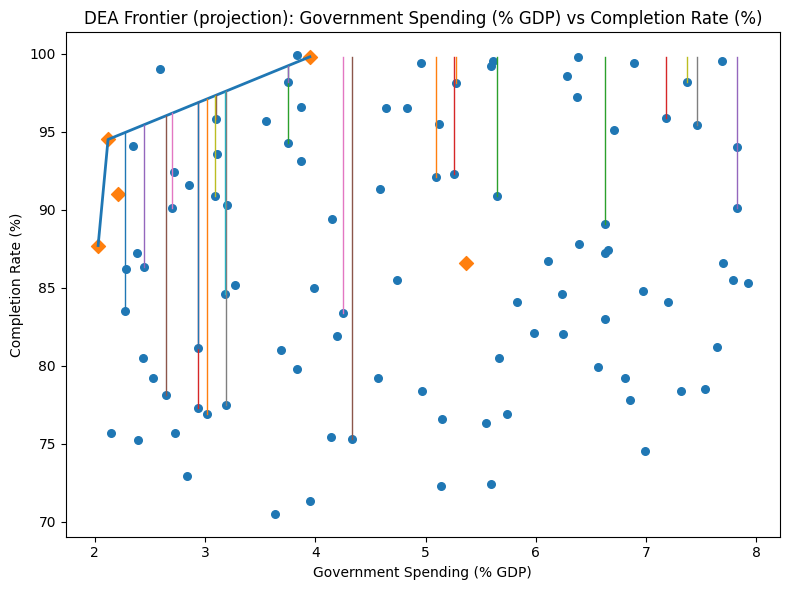

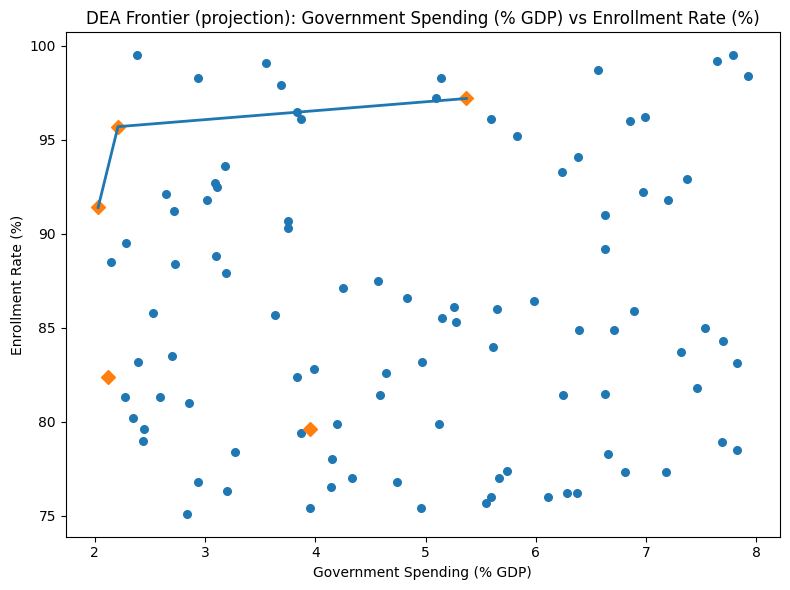

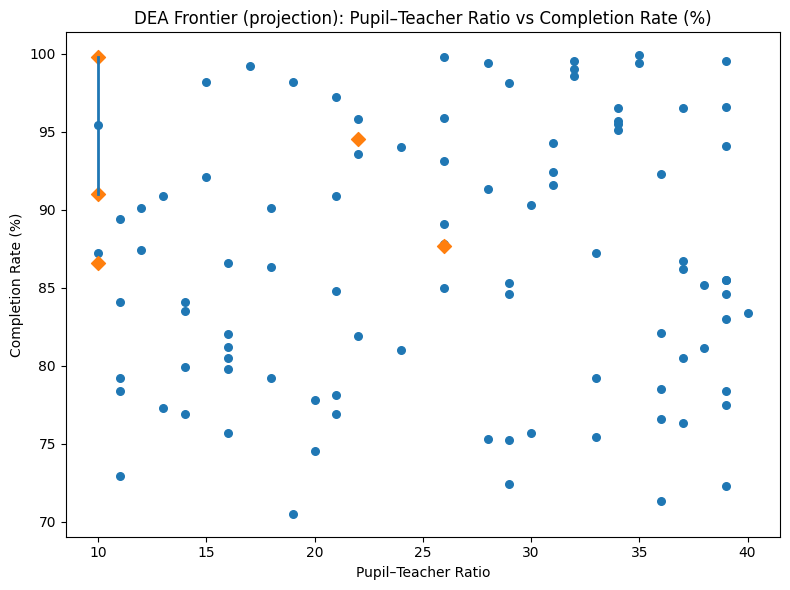

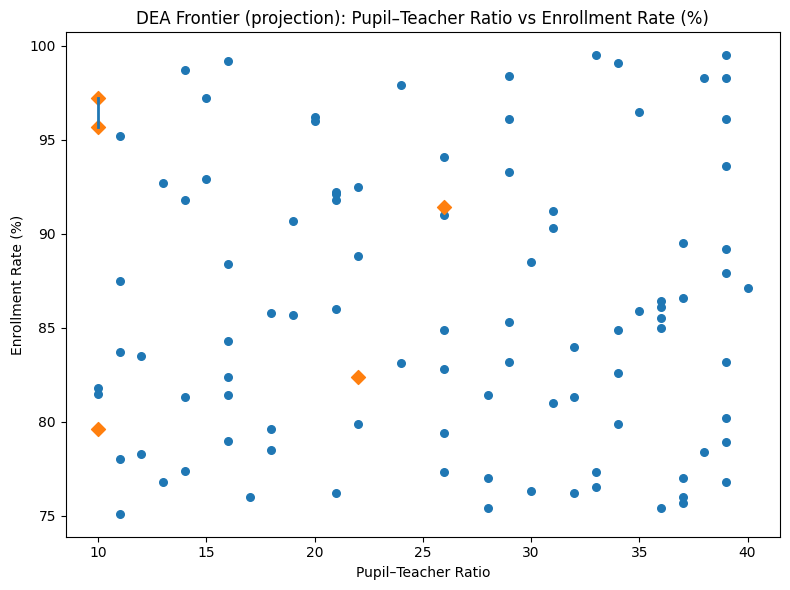

In [10]:
# --------------------------
# 7) Frontier (2D projection) utilities
# --------------------------
import numpy as np
import matplotlib.pyplot as plt

def compute_efficiencies_once(countries, inputs, outputs):
    effs = np.empty(len(countries), dtype=float)
    effs.fill(np.nan)
    for i in range(len(countries)):
        w, v, eff, ok = dea_opt_for_unit(i, inputs, outputs)
        effs[i] = eff if ok else np.nan
    return effs

def projected_frontier_points(x_vals, y_vals):
    """
    Build a monotone upper envelope from a set of efficient points in 2D.
    Steps:
      1) Sort by x ascending
      2) Keep points that increase the running max of y
      3) Return the polyline points (x_front, y_front)
    """
    order = np.argsort(x_vals)
    xs = x_vals[order]
    ys = y_vals[order]

    keep_x, keep_y = [], []
    cur_max = -np.inf
    for xi, yi in zip(xs, ys):
        if yi > cur_max:
            keep_x.append(xi)
            keep_y.append(yi)
            cur_max = yi

    return np.array(keep_x), np.array(keep_y)

def plot_frontier_projection(countries, inputs, outputs, x_idx=0, y_idx=0,
                             label_x=None, label_y=None, show_projections=False):
    """
    Plot a 2D projection of the DEA frontier:
      - x-axis: inputs[:, x_idx]
      - y-axis: outputs[:, y_idx]
    Steps:
      1) Compute efficiencies and efficient set (eff ~ 1)
      2) Build upper envelope of efficient points in this (x,y) plane
      3) Plot all countries, highlight efficient ones, draw the frontier polyline
      4) (Optional) draw vertical projection lines from inefficient points up to the envelope
         NOTE: This is a visual guide in the chosen 2D plane; the true DEA target is computed in full 4D.
    """
    # 1) Compute effs once
    effs = compute_efficiencies_once(countries, inputs, outputs)

    # 2) Pick data for this projection
    x = inputs[:, x_idx]
    y = outputs[:, y_idx]

    # 3) Efficient set (tolerance to account for solver precision)
    tol = 1e-6
    efficient_mask = np.isfinite(effs) & (effs >= 1.0 - tol)
    inef_mask = np.isfinite(effs) & ~efficient_mask

    # 4) Frontier from efficient points (upper envelope in the projection)
    x_eff = x[efficient_mask]
    y_eff = y[efficient_mask]
    if len(x_eff) >= 2:
        fx, fy = projected_frontier_points(x_eff, y_eff)
    else:
        fx, fy = x_eff, y_eff

    # 5) Plot
    plt.figure(figsize=(8, 6))
    # all points
    plt.scatter(x, y, s=30)
    # efficient points
    plt.scatter(x_eff, y_eff, s=50, marker="D")
    # frontier polyline
    if len(fx) >= 2:
        plt.plot(fx, fy, linewidth=2)

    # Optionally: draw simple vertical projections to the envelope (visual only)
    if show_projections and len(fx) >= 2:
        # Interpolate envelope y at each x (piecewise linear on (fx,fy))
        def frontier_y_at(xq):
            # find segment on fx where xq lies (left-closed, right-open)
            if xq <= fx[0]:
                return fy[0]
            if xq >= fx[-1]:
                return fy[-1]
            idx = np.searchsorted(fx, xq) - 1
            x0, x1 = fx[idx], fx[idx+1]
            y0, y1 = fy[idx], fy[idx+1]
            t = (xq - x0) / (x1 - x0) if x1 > x0 else 0.0
            return y0 + t * (y1 - y0)

        # draw projections for a subset (to avoid clutter, sample 25 inef points)
        inef_indices = np.where(inef_mask)[0]
        if len(inef_indices) > 25:
            inef_indices = np.random.choice(inef_indices, size=25, replace=False)
        for i in inef_indices:
            xi, yi = x[i], y[i]
            yi_front = frontier_y_at(xi)
            if yi_front >= yi:
                plt.plot([xi, xi], [yi, yi_front], linewidth=1)

    plt.xlabel(label_x or (["x1_spending", "x2_pupil_teacher"][x_idx]))
    plt.ylabel(label_y or (["y1_completion", "y2_enrollment"][y_idx]))
    plt.title(f"DEA Frontier (projection): {label_x or ['x1','x2'][x_idx]} vs {label_y or ['y1','y2'][y_idx]}")
    plt.tight_layout()
    plt.show()

# --------------------------
# 8) Example calls (choose any projections you want)
# --------------------------
# (a) Frontier in (x1, y1) plane
plot_frontier_projection(countries, inputs, outputs,
                         x_idx=0, y_idx=0,
                         label_x="Government Spending (% GDP)",
                         label_y="Completion Rate (%)",
                         show_projections=True)

# (b) Frontier in (x1, y2) plane
plot_frontier_projection(countries, inputs, outputs,
                         x_idx=0, y_idx=1,
                         label_x="Government Spending (% GDP)",
                         label_y="Enrollment Rate (%)",
                         show_projections=False)

# (c) Frontier in (x2, y1) plane
plot_frontier_projection(countries, inputs, outputs,
                         x_idx=1, y_idx=0,
                         label_x="Pupil–Teacher Ratio",
                         label_y="Completion Rate (%)",
                         show_projections=False)

# (d) Frontier in (x2, y2) plane
plot_frontier_projection(countries, inputs, outputs,
                         x_idx=1, y_idx=1,
                         label_x="Pupil–Teacher Ratio",
                         label_y="Enrollment Rate (%)",
                         show_projections=False)
